In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
!pip install nltk wordcloud contractions
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 7.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.1 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


True

In [6]:
import pandas as pd

# Correct paths based on your dataset structure
base_path = '/kaggle/input/datasets/sadikshyaghimire1/movie-review/5. Movie Review Dataset'

train_df = pd.read_csv(base_path + '/train_movie_review.csv')
val_df   = pd.read_csv(base_path + '/val_movie_review.csv')
test_df  = pd.read_csv(base_path + '/test_movie_review.csv')

# Quick verification
print("✅ Data Loaded Successfully!\n")
print("Train shape:", train_df.shape)
print("Val shape:  ", val_df.shape)
print("Test shape: ", test_df.shape)
print("\nFirst 3 rows:")
print(train_df.head(3))

✅ Data Loaded Successfully!

Train shape: (35000, 3)
Val shape:   (5000, 3)
Test shape:  (10000, 3)

First 3 rows:
   Unnamed: 0                                             review  sentiment
0        3774  Having avoided seeing the movie in the cinema,...          0
1       48396  With this movie I was really hoping that the i...          0
2        1980  Raymond Burr stars as an attorney caught up in...          0


In [7]:
print("=== Dataset Shapes ===")
print("Train shape:", train_df.shape)
print("Val shape:  ", val_df.shape)
print("Test shape: ", test_df.shape)

print("\n=== Column Names ===")
print(train_df.columns.tolist())

print("\n=== First 5 Rows (Train) ===")
display(train_df.head())

print("\n=== Data Info ===")
print(train_df.info())

print("\n=== Label Distribution (Train) ===")
print(train_df['label'].value_counts() if 'label' in train_df.columns else "No 'label' column found")
print(train_df['sentiment'].value_counts() if 'sentiment' in train_df.columns else "")

=== Dataset Shapes ===
Train shape: (35000, 3)
Val shape:   (5000, 3)
Test shape:  (10000, 3)

=== Column Names ===
['Unnamed: 0', 'review', 'sentiment']

=== First 5 Rows (Train) ===


,Unnamed: 0,review,sentiment
0,3774,"Having avoided seeing the movie in the cinema,...",0
1,48396,With this movie I was really hoping that the i...,0
2,1980,Raymond Burr stars as an attorney caught up in...,0
3,6703,A lot people get hung up on this films tag as ...,1
4,28168,I was a fan of Buffy and hoped it would come t...,0



=== Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  35000 non-null  int64 
 1   review      35000 non-null  object
 2   sentiment   35000 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 820.4+ KB
None

=== Label Distribution (Train) ===
No 'label' column found
sentiment
0    17584
1    17416
Name: count, dtype: int64


In [9]:
# Class Distribution
print("=== Class Distribution ===")
print("Train:\n", train_df['sentiment'].value_counts())
print("\nValidation:\n", val_df['sentiment'].value_counts())
print("\nTest:\n", test_df['sentiment'].value_counts())

# Basic Info
print("\n=== Sample Reviews ===")
print("Positive Example (sentiment=1):")
print(train_df[train_df['sentiment'] == 1]['review'].iloc[0][:400], "...\n")

print("Negative Example (sentiment=0):")
print(train_df[train_df['sentiment'] == 0]['review'].iloc[0][:400], "...")

=== Class Distribution ===
Train:
 sentiment
0    17584
1    17416
Name: count, dtype: int64

Validation:
 sentiment
1    2545
0    2455
Name: count, dtype: int64

Test:
 sentiment
1    5039
0    4961
Name: count, dtype: int64

=== Sample Reviews ===
Positive Example (sentiment=1):
A lot people get hung up on this films tag as a "children's film", and that it certainly is, though it is one made for adults. Takashi Miike uses the fantasy genre, particularly, the children's fantasy genre, as a springboard into the wild territory that is the Great Yokai War.<br /><br />The setup is simple a boy is selected to play the "hero" in this years annual festival, only to discover his r ...

Negative Example (sentiment=0):
Having avoided seeing the movie in the cinema, but buying the DVD for my wife for Xmas, I had to watch it. I did not expect much, which usually means I get more than I bargained for. But 'Mamma Mia' - utter, utter cr**. I like ABBA, I like the songs, I have the old LPs. But this

In [10]:
# Display first 5 rows nicely
display(train_df.head())

# Or if display() doesn't work well, use this:
print("First 5 rows:")
print(train_df.head())

,Unnamed: 0,review,sentiment
0,3774,"Having avoided seeing the movie in the cinema,...",0
1,48396,With this movie I was really hoping that the i...,0
2,1980,Raymond Burr stars as an attorney caught up in...,0
3,6703,A lot people get hung up on this films tag as ...,1
4,28168,I was a fan of Buffy and hoped it would come t...,0


First 5 rows:
   Unnamed: 0                                             review  sentiment
0        3774  Having avoided seeing the movie in the cinema,...          0
1       48396  With this movie I was really hoping that the i...          0
2        1980  Raymond Burr stars as an attorney caught up in...          0
3        6703  A lot people get hung up on this films tag as ...          1
4       28168  I was a fan of Buffy and hoped it would come t...          0


In [11]:
# Drop the unnamed index column
train_df = train_df.drop(columns=['Unnamed: 0'])
val_df   = val_df.drop(columns=['Unnamed: 0'])
test_df  = test_df.drop(columns=['Unnamed: 0'])

# Confirm
display(train_df.head())

,review,sentiment
0,"Having avoided seeing the movie in the cinema,...",0
1,With this movie I was really hoping that the i...,0
2,Raymond Burr stars as an attorney caught up in...,0
3,A lot people get hung up on this films tag as ...,1
4,I was a fan of Buffy and hoped it would come t...,0


In [12]:
import re
import contractions
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()                           # lowercase
    text = re.sub(r'<br\s*/?>', ' ', text)        # remove <br> tags first
    text = contractions.fix(text)                 # don't → do not
    text = re.sub(r'http\S+|www\S+', '', text)    # remove URLs
    text = re.sub(r'@\w+', '', text)              # remove mentions
    text = re.sub(r'#\w+', '', text)              # remove hashtags
    text = re.sub(r'\d+', '', text)               # remove numbers
    text = re.sub(r'[^a-z\s]', '', text)          # remove special characters
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

train_df['cleaned'] = train_df['review'].apply(clean_text)
val_df['cleaned']   = val_df['review'].apply(clean_text)
test_df['cleaned']  = test_df['review'].apply(clean_text)

print("Cleaning done!")
print(f"Train: {len(train_df)} rows")

Cleaning done!
Train: 35000 rows


In [13]:
for i in range(3):
    print(f"--- Example {i+1} ---")
    print(f"ORIGINAL: {train_df['review'].iloc[i][:200]}")
    print(f"CLEANED:  {train_df['cleaned'].iloc[i][:200]}")
    print()

--- Example 1 ---
ORIGINAL: Having avoided seeing the movie in the cinema, but buying the DVD for my wife for Xmas, I had to watch it. I did not expect much, which usually means I get more than I bargained for. But 'Mamma Mia' -
CLEANED:  avoided seeing movie cinema buying dvd wife xmas watch expect much usually mean get bargained mamma mia utter utter cr like abba like song old lp film terrible stage show look like bit musical race al

--- Example 2 ---
ORIGINAL: With this movie I was really hoping that the idea was to make up for the hashed together ineptitude of the first AVP, and yet to my horror: Requiem is far worse than I could have imagined.<br /><br />
CLEANED:  movie really hoping idea make hashed together ineptitude first avp yet horror requiem far worse could imagined hope opening moment film inside predator ship almost breathed sigh relief finally saw pre

--- Example 3 ---
ORIGINAL: Raymond Burr stars as an attorney caught up in the murder of his best friend (Dick Foran) 

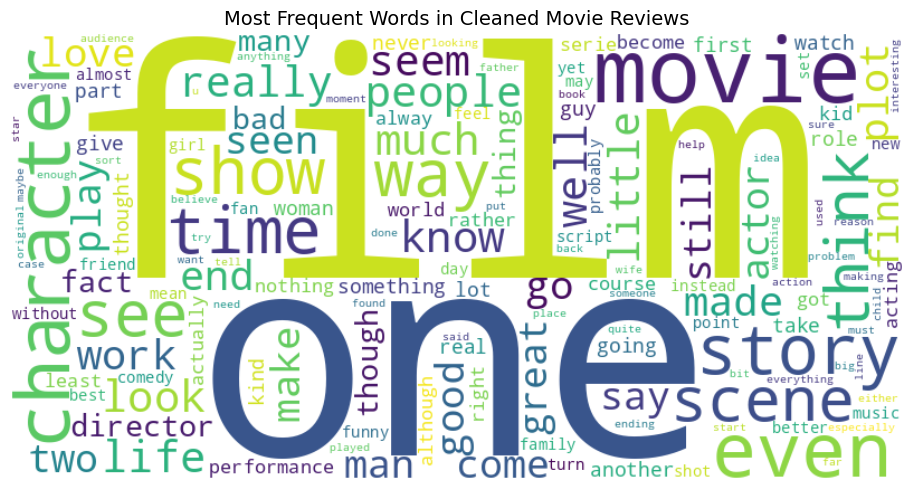

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text = ' '.join(train_df['cleaned'])

wc = WordCloud(width=800, height=400, background_color='white', max_words=150).generate(all_text)

plt.figure(figsize=(12, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Cleaned Movie Reviews', fontsize=14)
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150)
plt.show()

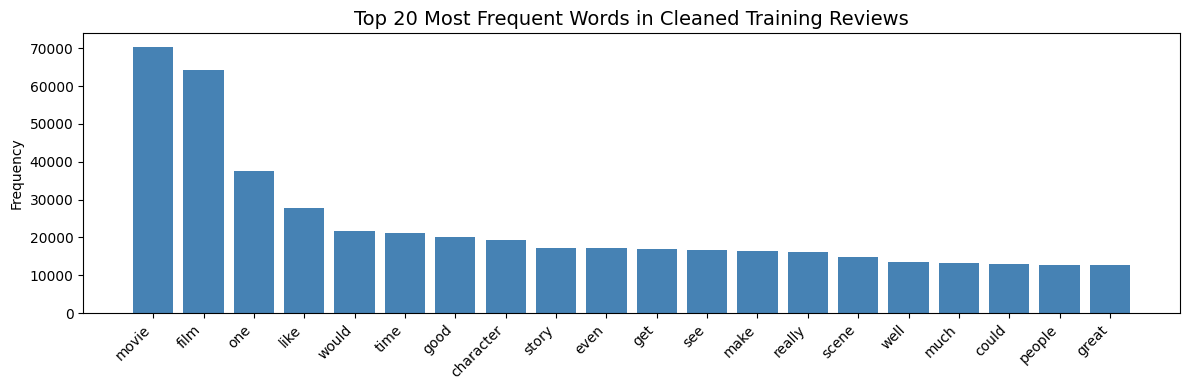

In [16]:
from collections import Counter

word_freq = Counter(' '.join(train_df['cleaned']).split())
top20 = word_freq.most_common(20)
words, counts = zip(*top20)

plt.figure(figsize=(12, 4))
plt.bar(words, counts, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most Frequent Words in Cleaned Training Reviews', fontsize=14)
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('top20_words.png', dpi=150)
plt.show()

In [17]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['cleaned'])  # fit on training data only

word_index = tokenizer.word_index
vocab_size = len(word_index) + 1

print(f"Vocabulary size: {vocab_size}")
print(f"Sample word indices:")
print(dict(list(word_index.items())[:10]))

2026-05-10 16:28:54.901514: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778430535.141407      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778430535.208457      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778430535.742555      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778430535.742581      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778430535.742584      57 computation_placer.cc:177] computation placer alr

Vocabulary size: 122062
Sample word indices:
{'<OOV>': 1, 'movie': 2, 'film': 3, 'one': 4, 'like': 5, 'would': 6, 'time': 7, 'good': 8, 'character': 9, 'story': 10}


In [18]:
X_train_seq = tokenizer.texts_to_sequences(train_df['cleaned'])
X_val_seq   = tokenizer.texts_to_sequences(val_df['cleaned'])
X_test_seq  = tokenizer.texts_to_sequences(test_df['cleaned'])

print(f"Sample sequence (first review):")
print(X_train_seq[0][:20], "...")

Sample sequence (first review):
[3871, 202, 2, 313, 2440, 162, 212, 15737, 33, 382, 18, 481, 167, 12, 13413, 28446, 8952, 1758, 1758, 20269] ...


Average sequence length:        116
Median sequence length:         87
90th percentile length:         229
95th percentile length:         301
99th percentile length:         454
Max sequence length:            1416


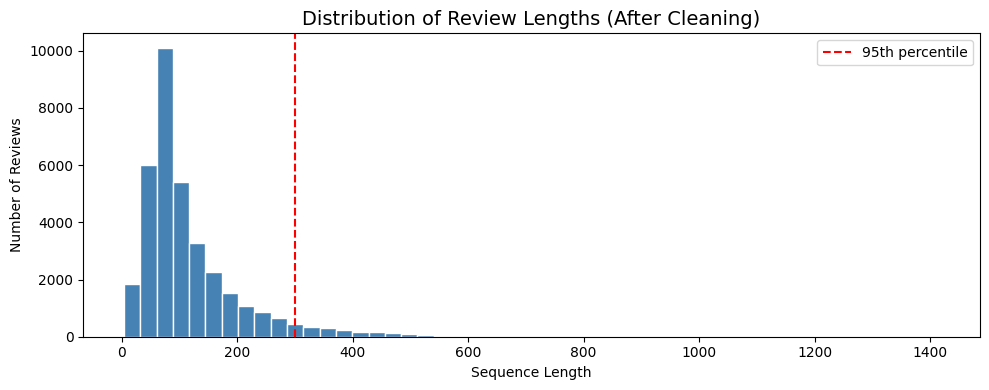

In [19]:
import numpy as np

lengths = [len(seq) for seq in X_train_seq]

print(f"Average sequence length:        {int(np.mean(lengths))}")
print(f"Median sequence length:         {int(np.median(lengths))}")
print(f"90th percentile length:         {int(np.percentile(lengths, 90))}")
print(f"95th percentile length:         {int(np.percentile(lengths, 95))}")
print(f"99th percentile length:         {int(np.percentile(lengths, 99))}")
print(f"Max sequence length:            {int(np.max(lengths))}")

# Visualise the distribution
plt.figure(figsize=(10, 4))
plt.hist(lengths, bins=50, color='steelblue', edgecolor='white')
plt.axvline(int(np.percentile(lengths, 95)), color='red', linestyle='--', label='95th percentile')
plt.title('Distribution of Review Lengths (After Cleaning)', fontsize=14)
plt.xlabel('Sequence Length')
plt.ylabel('Number of Reviews')
plt.legend()
plt.tight_layout()
plt.savefig('sequence_lengths.png', dpi=150)
plt.show()

In [20]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 301  # 95th percentile

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=max_len, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_len, padding='post', truncating='post')

y_train = train_df['sentiment'].values
y_val   = val_df['sentiment'].values
y_test  = test_df['sentiment'].values

print("Padded shapes:")
print(f"X_train: {X_train_pad.shape}")
print(f"X_val:   {X_val_pad.shape}")
print(f"X_test:  {X_test_pad.shape}")

Padded shapes:
X_train: (35000, 301)
X_val:   (5000, 301)
X_test:  (10000, 301)


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.optimizers import Adam

vocab_size    = 122062
embedding_dim = 64

model1 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    SimpleRNN(128, return_sequences=False),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

model1.build(input_shape=(None, max_len))

model1.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

model1.summary()

I0000 00:00:1778430825.057201      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778430825.063175      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 301, 64)        │     7,811,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,836,801 (29.90 MB)

 Trainable params: 7,836,801 (29.90 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
from tensorflow.keras.layers import LSTM

model2 = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    LSTM(128, return_sequences=True),
    LSTM(64, return_sequences=False), 
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model2.build(input_shape=(None, max_len))

model2.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 301, 64)        │     7,811,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 301, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,960,257 (30.37 MB)

 Trainable params: 7,960,257 (30.37 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
!pip install gensim --quiet

import gensim.downloader as api

print("Downloading Word2Vec embeddings... this may take a few minutes.")
embedding_model_w2v = api.load('word2vec-google-news-300')
print("Download complete!")

Download complete!


In [26]:
embedding_dim_w2v = 300  # Word2Vec is 300 dimensions

embedding_matrix = np.zeros((vocab_size, embedding_dim_w2v))
found = 0

for word, i in word_index.items():
    if word in embedding_model_w2v:
        embedding_matrix[i] = embedding_model_w2v[word]
        found += 1

print(f"Words found in Word2Vec:     {found}")
print(f"Words not found in Word2Vec: {vocab_size - found}")
print(f"Coverage:                    {found/vocab_size*100:.1f}%")

model3 = Sequential([
    Embedding(input_dim=vocab_size,
              output_dim=embedding_dim_w2v,
              weights=[embedding_matrix],
              trainable=True),
    LSTM(64, return_sequences=False),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model3.build(input_shape=(None, max_len))

model3.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

model3.summary()

Words found in Word2Vec:     47159
Words not found in Word2Vec: 74903
Coverage:                    38.6%


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 301, 300)       │    36,618,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        93,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,712,105 (140.05 MB)

 Trainable params: 36,712,105 (140.05 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Training Model 1 - Simple RNN...")
history1 = model1.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop],
    verbose=1
)

Training Model 1 - Simple RNN...
Epoch 1/15


I0000 00:00:1778432251.142661     207 service.cc:152] XLA service 0x220bbfd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778432251.142717     207 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778432251.142722     207 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778432251.540814     207 cuda_dnn.cc:529] Loaded cuDNN version 91002


  5/547 ━━━━━━━━━━━━━━━━━━━━ 17s 32ms/step - accuracy: 0.4908 - loss: 0.6974

I0000 00:00:1778432253.050728     207 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


547/547 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.4979 - loss: 0.7016 - val_accuracy: 0.5074 - val_loss: 0.6936
Epoch 2/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.5006 - loss: 0.7260 - val_accuracy: 0.5208 - val_loss: 0.6925
Epoch 3/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.4974 - loss: 0.7101 - val_accuracy: 0.5098 - val_loss: 0.6925
Epoch 4/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.4938 - loss: 0.7011 - val_accuracy: 0.5130 - val_loss: 0.6936
Epoch 5/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.5067 - loss: 0.6956 - val_accuracy: 0.5164 - val_loss: 0.6928
Epoch 6/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.5034 - loss: 0.6949 - val_accuracy: 0.5108 - val_loss: 0.6931


In [28]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Training Model 2 - LSTM...")
history2 = model2.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop],
    verbose=1
)

Training Model 2 - LSTM...
Epoch 1/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.5004 - loss: 0.6934 - val_accuracy: 0.4948 - val_loss: 0.6931
Epoch 2/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 16s 30ms/step - accuracy: 0.5057 - loss: 0.6927 - val_accuracy: 0.5128 - val_loss: 0.6916
Epoch 3/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.5255 - loss: 0.6807 - val_accuracy: 0.5154 - val_loss: 0.6998
Epoch 4/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.5278 - loss: 0.6624 - val_accuracy: 0.5070 - val_loss: 0.7093
Epoch 5/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.5405 - loss: 0.6499 - val_accuracy: 0.8234 - val_loss: 0.4377
Epoch 6/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.8569 - loss: 0.3640 - val_accuracy: 0.8712 - val_loss: 0.3353
Epoch 7/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accuracy: 0.9303 - loss: 0.2003 - val_accuracy: 0.8684 - val_loss: 0.3177
Epoch 8/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - accurac

In [29]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("Training Model 3 - LSTM with Word2Vec embeddings...")
history3 = model3.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop],
    verbose=1
)

Training Model 3 - LSTM with Word2Vec embeddings...
Epoch 1/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.5015 - loss: 0.6929 - val_accuracy: 0.5040 - val_loss: 0.6893
Epoch 2/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.5119 - loss: 0.6881 - val_accuracy: 0.5052 - val_loss: 0.6874
Epoch 3/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.5197 - loss: 0.6717 - val_accuracy: 0.5186 - val_loss: 0.6926
Epoch 4/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.5217 - loss: 0.6629 - val_accuracy: 0.5050 - val_loss: 0.6972
Epoch 5/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.7164 - loss: 0.5364 - val_accuracy: 0.8496 - val_loss: 0.3675
Epoch 6/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.9094 - loss: 0.2550 - val_accuracy: 0.8830 - val_loss: 0.2971
Epoch 7/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 19s 35ms/step - accuracy: 0.9589 - loss: 0.1393 - val_accuracy: 0.8822 - val_loss: 0.3125
Epoch 8/15
547/547 ━━━━━━━━━━━━━━━━━━━

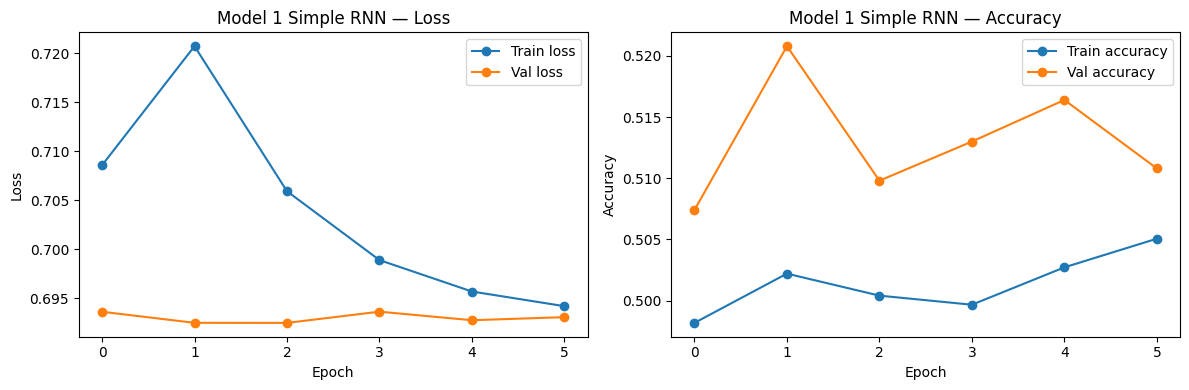

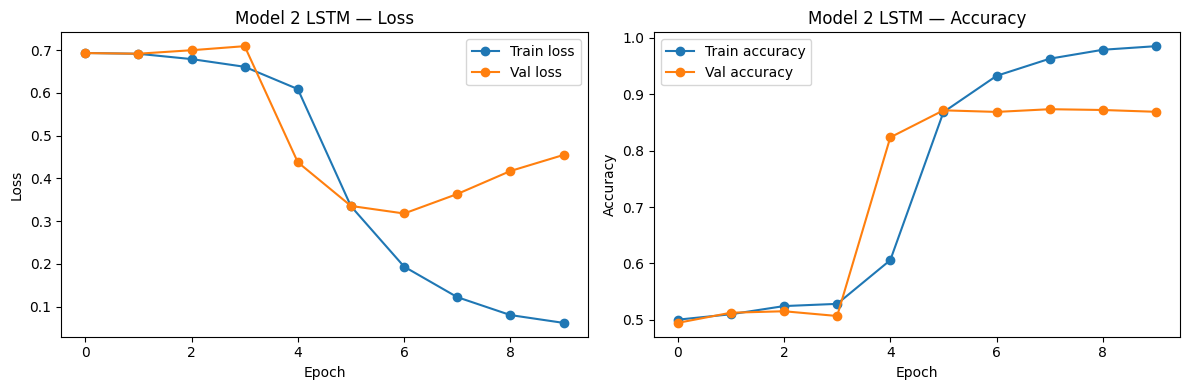

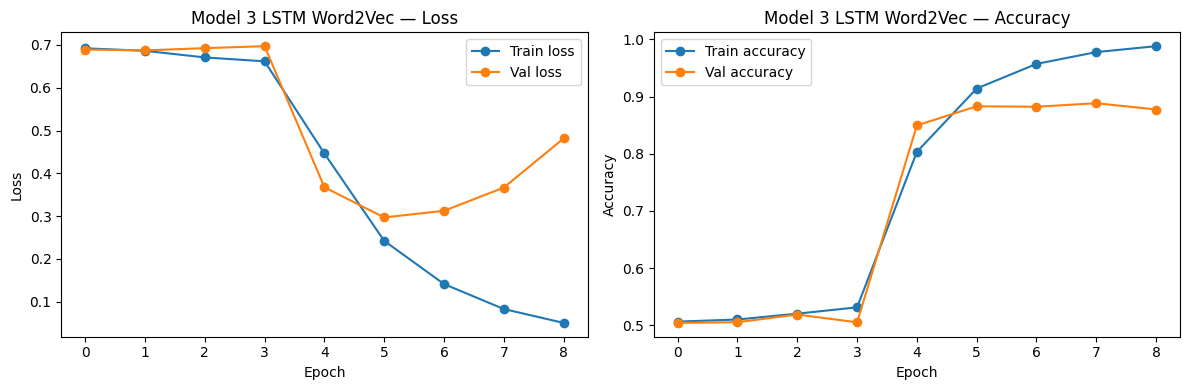

In [30]:
import matplotlib.pyplot as plt

def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history['loss'], label='Train loss', marker='o')
    ax1.plot(history.history['val_loss'], label='Val loss', marker='o')
    ax1.set_title(f'{title} — Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(history.history['accuracy'], label='Train accuracy', marker='o')
    ax2.plot(history.history['val_accuracy'], label='Val accuracy', marker='o')
    ax2.set_title(f'{title} — Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}_curves.png', dpi=150)
    plt.show()

plot_history(history1, 'Model 1 Simple RNN')
plot_history(history2, 'Model 2 LSTM')
plot_history(history3, 'Model 3 LSTM Word2Vec')

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step

Model 1 Simple RNN
Test Accuracy: 0.5064

Classification Report:
              precision    recall  f1-score   support

    Negative       0.50      0.55      0.53      4961
    Positive       0.51      0.46      0.49      5039

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.51     10000
weighted avg       0.51      0.51      0.51     10000



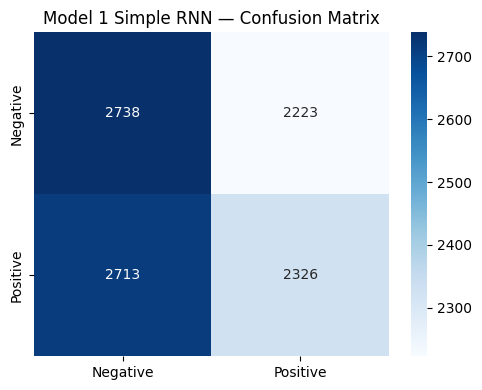

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step

Model 2 LSTM
Test Accuracy: 0.8731

Classification Report:
              precision    recall  f1-score   support

    Negative       0.87      0.88      0.87      4961
    Positive       0.88      0.87      0.87      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



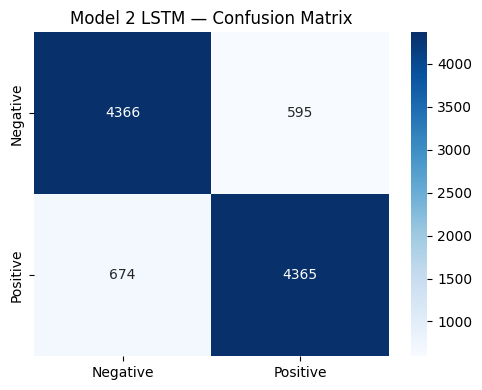

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

Model 3 LSTM Word2Vec
Test Accuracy: 0.8877

Classification Report:
              precision    recall  f1-score   support

    Negative       0.88      0.90      0.89      4961
    Positive       0.90      0.88      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



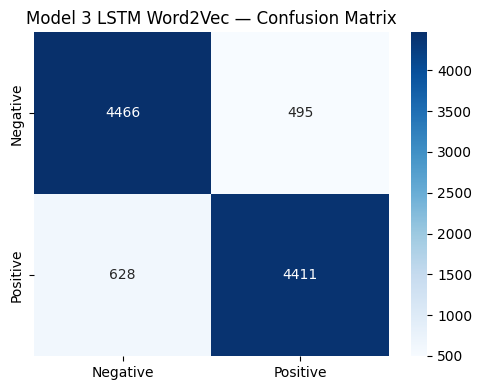

In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

def evaluate_model(model, name):
    y_pred_prob = model.predict(X_test_pad)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    acc = accuracy_score(y_test, y_pred)
    print(f'\n{"="*50}')
    print(f'{name}')
    print(f'{"="*50}')
    print(f'Test Accuracy: {acc:.4f}')
    print(f'\nClassification Report:')
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    plt.title(f'{name} — Confusion Matrix')
    plt.tight_layout()
    plt.savefig(f'{name.replace(" ", "_")}_cm.png', dpi=150)
    plt.show()

    return acc

acc1 = evaluate_model(model1, 'Model 1 Simple RNN')
acc2 = evaluate_model(model2, 'Model 2 LSTM')
acc3 = evaluate_model(model3, 'Model 3 LSTM Word2Vec')

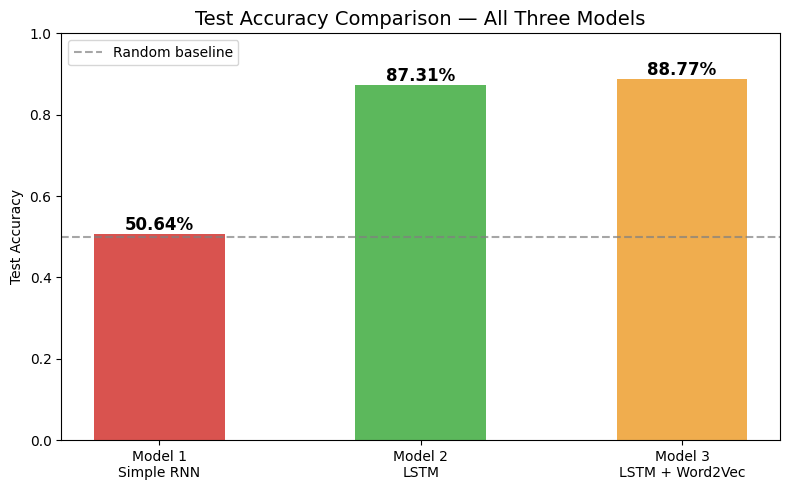

In [34]:
models = ['Model 1\nSimple RNN', 'Model 2\nLSTM', 'Model 3\nLSTM + Word2Vec']
accuracies = [0.5064, 0.8731, 0.8877]  # ← update 0.5706 with your actual Word2Vec result
colors = ['#d9534f', '#5cb85c', '#f0ad4e']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=colors, width=0.5)
plt.ylim(0, 1.0)
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Random baseline')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.2%}', ha='center', fontsize=12, fontweight='bold')
plt.title('Test Accuracy Comparison — All Three Models', fontsize=14)
plt.ylabel('Test Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

In [35]:
import numpy as np

y_pred_prob2 = model2.predict(X_test_pad)
y_pred2 = (y_pred_prob2 > 0.5).astype(int).flatten()

# Find misclassified indices
errors = np.where(y_pred2 != y_test)[0]
print(f"Total misclassified by Model 2: {len(errors)} out of {len(y_test)}")
print(f"Error rate: {len(errors)/len(y_test)*100:.2f}%\n")

# Display 5 misclassified examples
for i in errors[:5]:
    true_label = "Positive" if y_test[i] == 1 else "Negative"
    pred_label = "Positive" if y_pred2[i] == 1 else "Negative"
    confidence = float(y_pred_prob2[i][0])
    if y_pred2[i] == 0:
        confidence = 1 - confidence
    print(f"--- Example {i} ---")
    print(f"Original review: {test_df['review'].iloc[i][:300]}")
    print(f"Cleaned review:  {test_df['cleaned'].iloc[i][:200]}")
    print(f"True label:      {true_label}")
    print(f"Predicted:       {pred_label}")
    print(f"Confidence:      {confidence:.2%}")
    print()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Total misclassified by Model 2: 1269 out of 10000
Error rate: 12.69%

--- Example 0 ---
Original review: I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok 
Cleaned review:  really liked summerslam due look arena curtain look overall interesting reason anyways could one best summerslams ever wwf lex luger main event yokozuna time ok huge fat man v strong man glad time cha
True label:      Positive
Predicted:       Negative
Confidence:      97.72%

--- Example 7 ---
Original review: Okay, I didn't get the Purgatory thing the first time I watched this episode. It seemed like something significant was going on that I couldn't put my finger on. This time those Costa Mesa fires on TV really caught my atten

In [36]:
results = {
    'Model': ['Simple RNN', 'LSTM', 'LSTM + Word2Vec'],
    'Test Accuracy': ['50.64%', '87.31%', '88.77%'],
    'Precision (avg)': ['0.51', '0.87', '0.89'],
    'Recall (avg)': ['0.51', '0.87', '0.89'],
    'F1-Score (avg)': ['0.51', '0.87', '0.89'],
    'Epochs Run': [6, 10, 9]
}

results_df = pd.DataFrame(results)
display(results_df)

,Model,Test Accuracy,Precision (avg),Recall (avg),F1-Score (avg),Epochs Run
0,Simple RNN,50.64%,0.51,0.51,0.51,6
1,LSTM,87.31%,0.87,0.87,0.87,10
2,LSTM + Word2Vec,88.77%,0.89,0.89,0.89,9


In [37]:
!pip install gradio --quiet
print("Gradio installed!")

Gradio installed!


In [38]:
import pickle

# Save tokenizer
with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved!")
print(f"Model 2 ready: {model2.built}")
print(f"Max length: {max_len}")
print(f"Vocab size: {vocab_size}")

Tokenizer saved!
Model 2 ready: True
Max length: 301
Vocab size: 122062


In [39]:
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_sentiment(review):
    # Clean the input
    cleaned = clean_text(review)

    # Tokenize and pad
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')

    # Predict
    prob = float(model2.predict(padded, verbose=0)[0][0])

    if prob > 0.5:
        label = "Positive 😊"
        confidence = prob
    else:
        label = "Negative 😞"
        confidence = 1 - prob

    return {
        "Sentiment": label,
        "Confidence": f"{confidence:.2%}",
        "Positive probability": f"{prob:.2%}",
        "Negative probability": f"{1-prob:.2%}"
    }

# Build the interface
demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(
        lines=5,
        placeholder="Enter a movie review here...",
        label="Movie Review"
    ),
    outputs=gr.JSON(label="Prediction Results"),
    title="🎬 Movie Review Sentiment Analyser",
    description="Enter any movie review and the LSTM model will predict whether it is positive or negative.",
    examples=[
        ["This movie was absolutely fantastic! The acting was superb and the story kept me engaged throughout."],
        ["What a waste of time. Terrible acting, boring plot and I almost fell asleep halfway through."],
        ["It was okay, nothing special but not terrible either. Some good moments but mostly forgettable."]
    ]
)

demo.launch(share=True, debug=False)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://d984f9409949e815e0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
